# Tech Challenge — Predição de Obesidade

Este projeto tem como objetivo desenvolver uma solução de Machine Learning para auxiliar uma equipe médica na previsão do nível de obesidade de uma pessoa, com base em informações demográficas, comportamentais, alimentares e de estilo de vida.

A solução contempla:

- análise exploratória dos dados;
- preparação e tratamento da base;
- criação de uma pipeline de Machine Learning;
- treinamento e comparação de modelos;
- escolha do melhor modelo;
- deploy em uma aplicação preditiva com Streamlit;
- construção de uma visão analítica com os principais insights para a equipe médica.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

import joblib

In [2]:
df = pd.read_csv('/content/Obesity.csv')
df.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [3]:
df['Obesity'].value_counts()

,count
Obesity,
Obesity_Type_I,351
Obesity_Type_III,324
Obesity_Type_II,297
Overweight_Level_I,290
Overweight_Level_II,290
Normal_Weight,287
Insufficient_Weight,272


In [4]:
df['Obesity'].value_counts(normalize=True) * 100

,proportion
Obesity,
Obesity_Type_I,16.627191
Obesity_Type_III,15.348176
Obesity_Type_II,14.069162
Overweight_Level_I,13.737565
Overweight_Level_II,13.737565
Normal_Weight,13.595452
Insufficient_Weight,12.884889


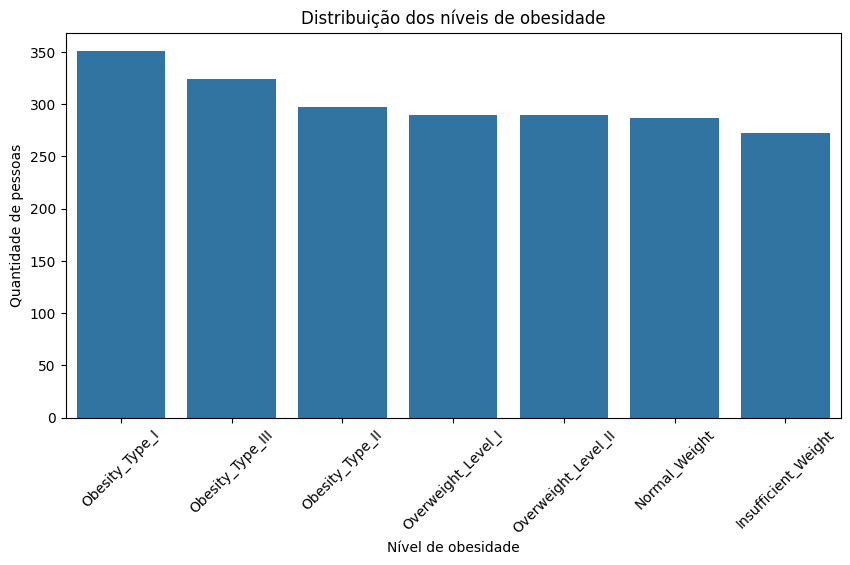

In [5]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='Obesity', order=df['Obesity'].value_counts().index)
plt.xticks(rotation=45)
plt.title('Distribuição dos níveis de obesidade')
plt.xlabel('Nível de obesidade')
plt.ylabel('Quantidade de pessoas')
plt.show()

A variável alvo do modelo é o nível de obesidade. A base apresenta diferentes classes, desde peso insuficiente até obesidade tipo III. Essa distribuição é importante porque permite avaliar se o modelo terá classes equilibradas ou se haverá maior dificuldade para prever categorias menos representadas.

In [6]:
df.isnull().sum()

,0
Gender,0
Age,0
Height,0
Weight,0
family_history,0
FAVC,0
FCVC,0
NCP,0
CAEC,0
SMOKE,0


In [7]:
df.duplicated().sum()

np.int64(24)

In [8]:
df = df.drop_duplicates()

In [9]:
df.shape

(2087, 17)

Nesta etapa, foi verificada a presença de valores ausentes e registros duplicados. Esse processo é importante para garantir que o modelo seja treinado com dados consistentes e reduzir possíveis distorções na etapa de aprendizado.

In [11]:
scale_cols = ['FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

for col in scale_cols:
    df[col + '_round'] = df[col].round()

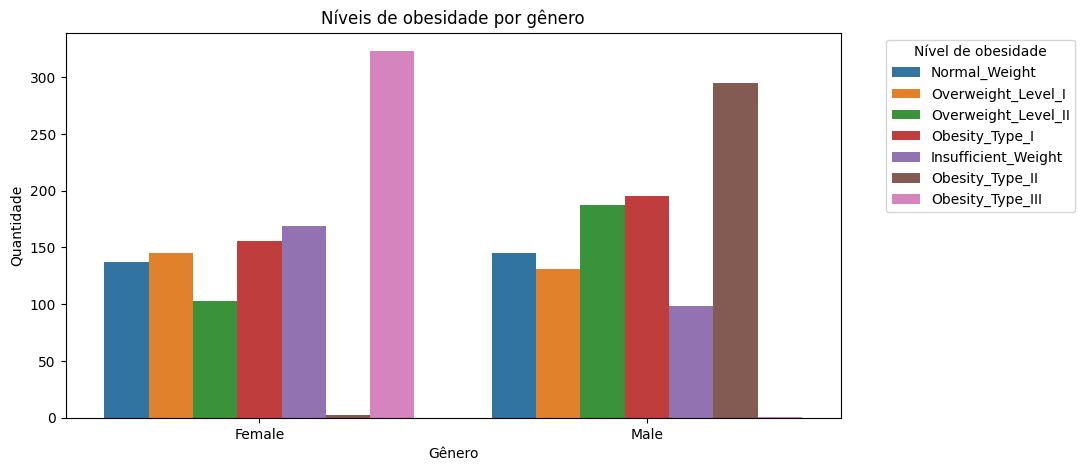

In [12]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='Gender', hue='Obesity')
plt.title('Níveis de obesidade por gênero')
plt.xlabel('Gênero')
plt.ylabel('Quantidade')
plt.legend(title='Nível de obesidade', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

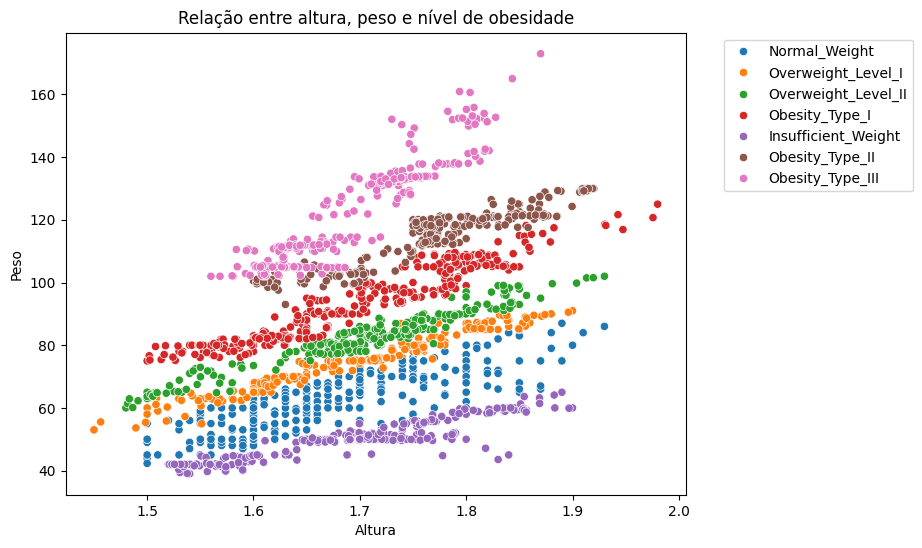

In [13]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Height', y='Weight', hue='Obesity')
plt.title('Relação entre altura, peso e nível de obesidade')
plt.xlabel('Altura')
plt.ylabel('Peso')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

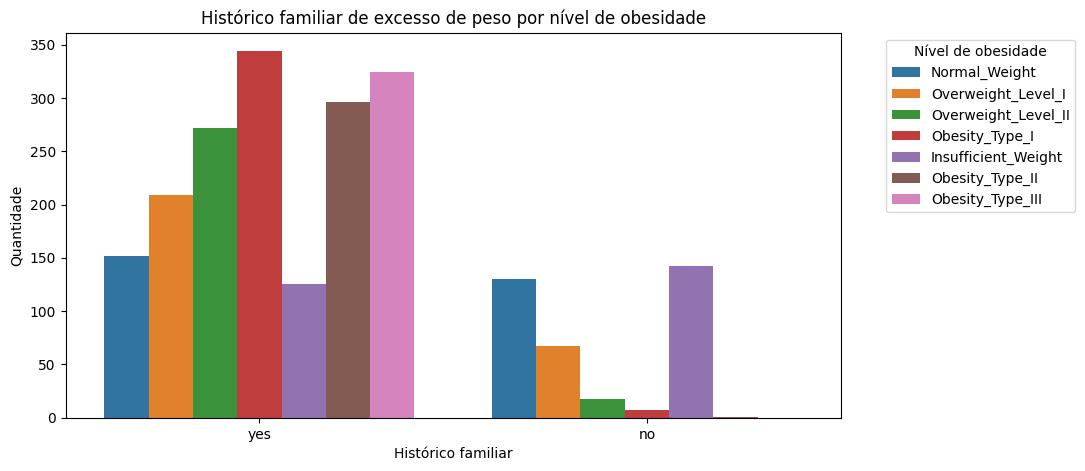

In [14]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='family_history', hue='Obesity')
plt.title('Histórico familiar de excesso de peso por nível de obesidade')
plt.xlabel('Histórico familiar')
plt.ylabel('Quantidade')
plt.legend(title='Nível de obesidade', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

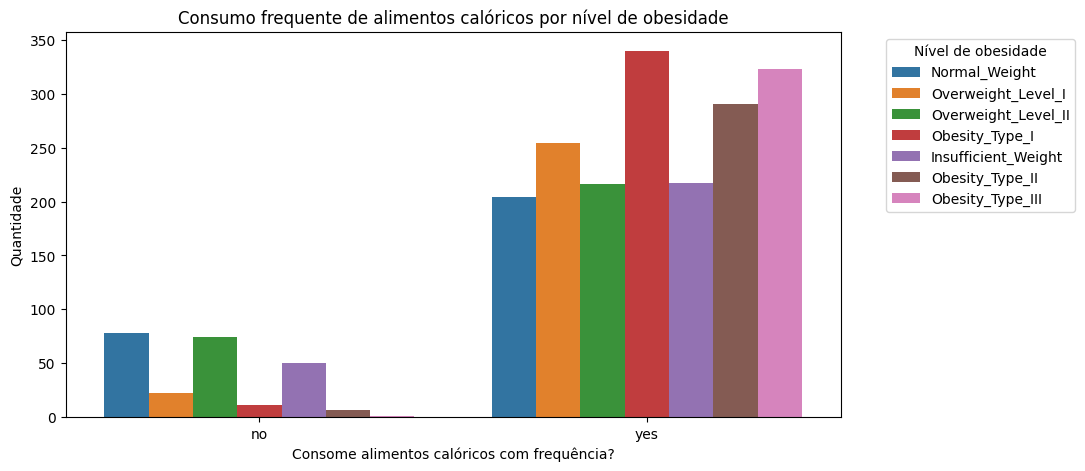

In [15]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='FAVC', hue='Obesity')
plt.title('Consumo frequente de alimentos calóricos por nível de obesidade')
plt.xlabel('Consome alimentos calóricos com frequência?')
plt.ylabel('Quantidade')
plt.legend(title='Nível de obesidade', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

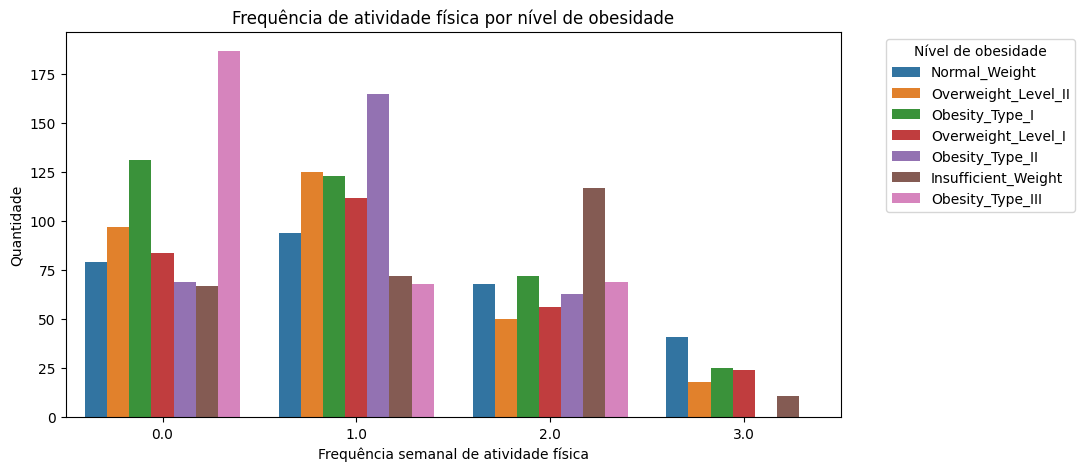

In [16]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='FAF_round', hue='Obesity')
plt.title('Frequência de atividade física por nível de obesidade')
plt.xlabel('Frequência semanal de atividade física')
plt.ylabel('Quantidade')
plt.legend(title='Nível de obesidade', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

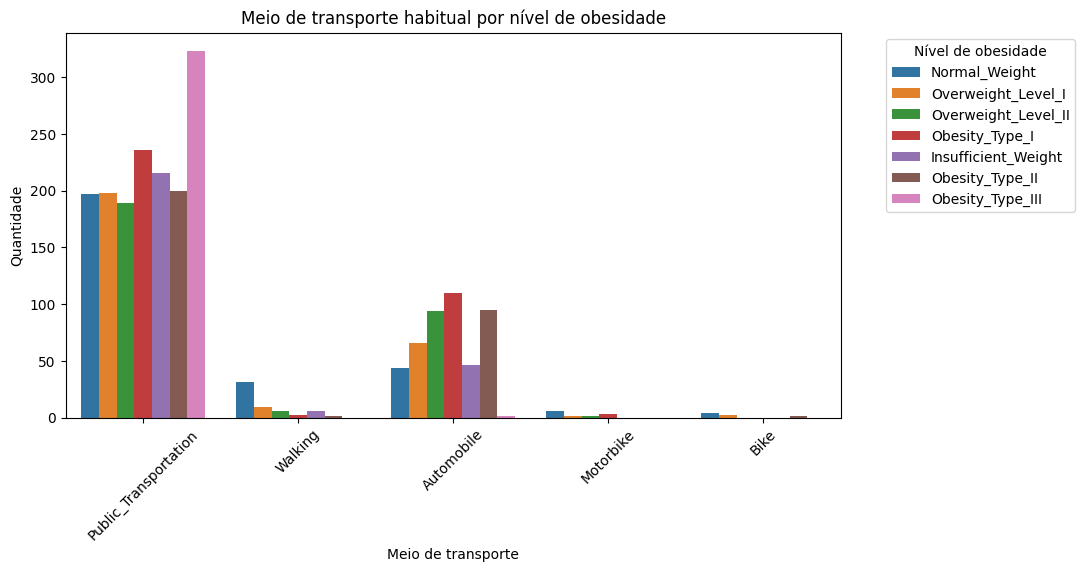

In [17]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='MTRANS', hue='Obesity')
plt.title('Meio de transporte habitual por nível de obesidade')
plt.xlabel('Meio de transporte')
plt.ylabel('Quantidade')
plt.xticks(rotation=45)
plt.legend(title='Nível de obesidade', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [18]:
df['BMI'] = df['Weight'] / (df['Height'] ** 2)

In [19]:
df[['Height', 'Weight', 'BMI', 'Obesity']].head()

,Height,Weight,BMI,Obesity
0,1.62,64.0,24.386526,Normal_Weight
1,1.52,56.0,24.238227,Normal_Weight
2,1.80,77.0,23.765432,Normal_Weight
3,1.80,87.0,26.851852,Overweight_Level_I
4,1.78,89.8,28.342381,Overweight_Level_II


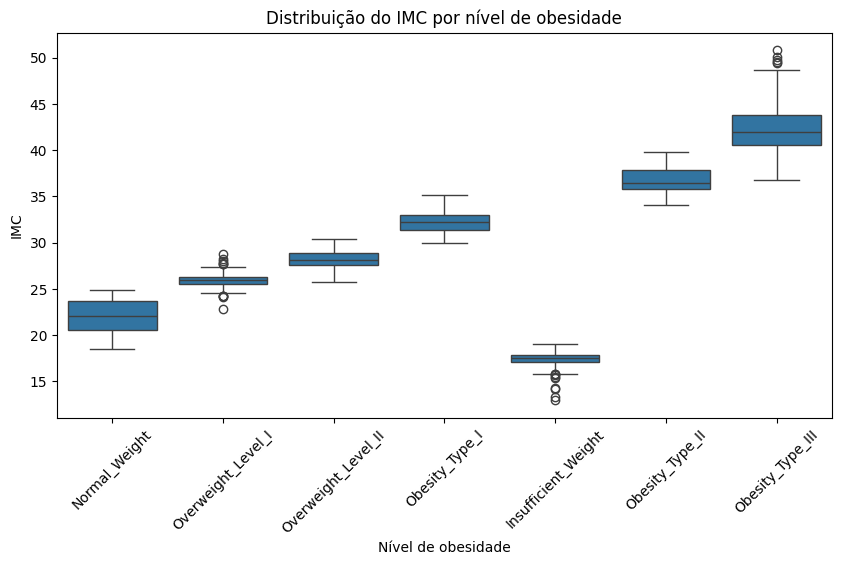

In [20]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='Obesity', y='BMI')
plt.xticks(rotation=45)
plt.title('Distribuição do IMC por nível de obesidade')
plt.xlabel('Nível de obesidade')
plt.ylabel('IMC')
plt.show()

In [21]:
X = df.drop(columns=['Obesity'])
y = df['Obesity']

In [22]:
X = df.drop(columns=['Obesity', 'FCVC_round', 'NCP_round', 'CH2O_round', 'FAF_round', 'TUE_round'])
y = df['Obesity']

In [23]:
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print('Categóricas:', categorical_features)
print('Numéricas:', numeric_features)

Categóricas: ['Gender', 'family_history', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']
Numéricas: ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE', 'BMI']


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [25]:
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [26]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

results = {}

for name, model in models.items():
    clf = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy

    print(f'{name}: {accuracy:.4f}')

Logistic Regression: 0.9258
Decision Tree: 0.9689
Random Forest: 0.9785
Gradient Boosting: 0.9761


In [27]:
results_df = pd.DataFrame({
    'Modelo': results.keys(),
    'Acurácia': results.values()
}).sort_values(by='Acurácia', ascending=False)

results_df

,Modelo,Acurácia
2,Random Forest,0.978469
3,Gradient Boosting,0.976077
1,Decision Tree,0.968900
0,Logistic Regression,0.925837


In [28]:
best_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced'
)

final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', best_model)
])

final_pipeline.fit(X_train, y_train)

y_pred = final_pipeline.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f'Acurácia final: {accuracy:.4f}')

Acurácia final: 0.9809


In [29]:
print(classification_report(y_test, y_pred))

                     precision    recall  f1-score   support

Insufficient_Weight       1.00      1.00      1.00        53
      Normal_Weight       0.90      1.00      0.95        57
     Obesity_Type_I       1.00      0.99      0.99        70
    Obesity_Type_II       0.98      1.00      0.99        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       1.00      0.93      0.96        55
Overweight_Level_II       0.98      0.97      0.97        58

           accuracy                           0.98       418
          macro avg       0.98      0.98      0.98       418
       weighted avg       0.98      0.98      0.98       418



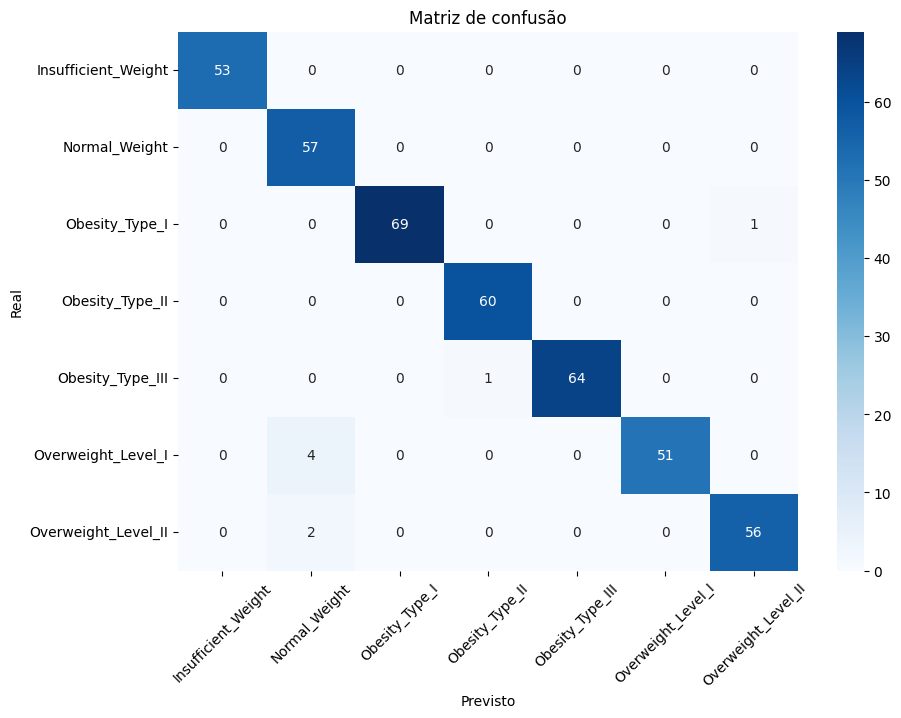

In [30]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=final_pipeline.classes_,
            yticklabels=final_pipeline.classes_)
plt.title('Matriz de confusão')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

O modelo escolhido foi o Random Forest, pois apresentou a melhor performance entre os modelos testados e superou a meta mínima de 75% de assertividade proposta no desafio.

A matriz de confusão permite avaliar em quais classes o modelo acerta mais e onde ocorrem confusões. Esse ponto é importante em um contexto médico, pois o modelo deve ser utilizado como ferramenta de apoio à decisão, e não como substituto da avaliação profissional.

In [31]:
joblib.dump(final_pipeline, 'modelo_obesidade.pkl')

['modelo_obesidade.pkl']

In [32]:
import os

os.makedirs('/content/tech-challenge-obesity/data', exist_ok=True)
os.makedirs('/content/tech-challenge-obesity/app', exist_ok=True)
os.makedirs('/content/tech-challenge-obesity/models', exist_ok=True)

In [33]:
import joblib

joblib.dump(final_pipeline, '/content/tech-challenge-obesity/models/modelo_obesidade.pkl')

['/content/tech-challenge-obesity/models/modelo_obesidade.pkl']

In [34]:
os.listdir('/content/tech-challenge-obesity/models')

['modelo_obesidade.pkl']

In [35]:
import shutil

shutil.copy('/content/Obesity.csv', '/content/tech-challenge-obesity/data/Obesity.csv')

'/content/tech-challenge-obesity/data/Obesity.csv'

In [36]:
os.listdir('/content/tech-challenge-obesity/data')

['Obesity.csv']

In [37]:
%%writefile /content/tech-challenge-obesity/app/app.py

import streamlit as st
import pandas as pd
import joblib
import os

BASE_DIR = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))
MODEL_PATH = os.path.join(BASE_DIR, 'models', 'modelo_obesidade.pkl')
DATA_PATH = os.path.join(BASE_DIR, 'data', 'Obesity.csv')

model = joblib.load(MODEL_PATH)
df = pd.read_csv(DATA_PATH)

st.set_page_config(
    page_title='Sistema Preditivo de Obesidade',
    page_icon='🩺',
    layout='wide'
)

st.title('🩺 Sistema Preditivo de Nível de Obesidade')

st.markdown("""
Esta aplicação utiliza um modelo de Machine Learning para estimar o nível de obesidade de uma pessoa com base em informações demográficas, alimentares, comportamentais e de estilo de vida.

A solução tem como objetivo apoiar a equipe médica na identificação de perfis de risco e na tomada de decisão clínica.
""")

tab1, tab2, tab3 = st.tabs([
    'Sistema Preditivo',
    'Dashboard Analítico',
    'Sobre o Projeto'
])

with tab1:
    st.header('Previsão individual')

    st.sidebar.header('Informações do paciente')

    gender = st.sidebar.selectbox('Gênero', ['Female', 'Male'])
    age = st.sidebar.slider('Idade', 14, 61, 25)
    height = st.sidebar.number_input('Altura em metros', min_value=1.40, max_value=2.10, value=1.70, step=0.01)
    weight = st.sidebar.number_input('Peso em kg', min_value=35.0, max_value=180.0, value=70.0, step=0.5)

    family_history = st.sidebar.selectbox('Histórico familiar de excesso de peso?', ['yes', 'no'])
    favc = st.sidebar.selectbox('Consome alimentos calóricos com frequência?', ['yes', 'no'])

    fcvc = st.sidebar.slider('Frequência de consumo de vegetais', 1.0, 3.0, 2.0, 1.0)
    ncp = st.sidebar.slider('Número de refeições principais por dia', 1.0, 4.0, 3.0, 1.0)

    caec = st.sidebar.selectbox('Come entre as refeições?', ['no', 'Sometimes', 'Frequently', 'Always'])
    smoke = st.sidebar.selectbox('Fuma?', ['yes', 'no'])

    ch2o = st.sidebar.slider('Consumo diário de água', 1.0, 3.0, 2.0, 1.0)
    scc = st.sidebar.selectbox('Monitora calorias diariamente?', ['yes', 'no'])

    faf = st.sidebar.slider('Frequência de atividade física semanal', 0.0, 3.0, 1.0, 1.0)
    tue = st.sidebar.slider('Tempo usando dispositivos eletrônicos', 0.0, 2.0, 1.0, 1.0)

    calc = st.sidebar.selectbox('Consumo de álcool', ['no', 'Sometimes', 'Frequently', 'Always'])
    mtrans = st.sidebar.selectbox(
        'Meio de transporte habitual',
        ['Automobile', 'Motorbike', 'Bike', 'Public_Transportation', 'Walking']
    )

    bmi = weight / (height ** 2)

    input_data = pd.DataFrame({
        'Gender': [gender],
        'Age': [age],
        'Height': [height],
        'Weight': [weight],
        'family_history': [family_history],
        'FAVC': [favc],
        'FCVC': [fcvc],
        'NCP': [ncp],
        'CAEC': [caec],
        'SMOKE': [smoke],
        'CH2O': [ch2o],
        'SCC': [scc],
        'FAF': [faf],
        'TUE': [tue],
        'CALC': [calc],
        'MTRANS': [mtrans],
        'BMI': [bmi]
    })

    col1, col2, col3 = st.columns(3)

    with col1:
        st.metric('Idade', age)

    with col2:
        st.metric('IMC estimado', round(bmi, 2))

    with col3:
        st.metric('Peso', f'{weight} kg')

    st.subheader('Dados informados')
    st.dataframe(input_data)

    if st.button('Gerar previsão'):
        prediction = model.predict(input_data)[0]
        prediction_proba = model.predict_proba(input_data).max()

        st.success(f'Nível previsto: {prediction}')
        st.info(f'Confiança estimada do modelo: {prediction_proba:.2%}')

        st.warning('Este resultado deve ser utilizado como apoio à decisão e não substitui avaliação médica individualizada.')

with tab2:
    st.header('Dashboard Analítico')

    st.subheader('Distribuição dos níveis de obesidade')
    obesity_counts = df['Obesity'].value_counts()
    st.bar_chart(obesity_counts)

    st.subheader('IMC médio por nível de obesidade')

    if 'BMI' not in df.columns:
        df['BMI'] = df['Weight'] / (df['Height'] ** 2)

    bmi_by_obesity = df.groupby('Obesity')['BMI'].mean().sort_values()
    st.bar_chart(bmi_by_obesity)

    st.subheader('Peso médio por nível de obesidade')
    weight_by_obesity = df.groupby('Obesity')['Weight'].mean().sort_values()
    st.bar_chart(weight_by_obesity)

    st.subheader('Histórico familiar de excesso de peso')
    family_table = pd.crosstab(df['family_history'], df['Obesity'])
    st.dataframe(family_table)

    st.subheader('Consumo frequente de alimentos calóricos')
    favc_table = pd.crosstab(df['FAVC'], df['Obesity'])
    st.dataframe(favc_table)

    st.subheader('Principais insights para a equipe médica')

    st.markdown("""
    - O IMC médio aumenta de forma consistente conforme o nível de obesidade se torna mais elevado.
    - O histórico familiar de excesso de peso pode ser usado como um sinal importante para triagem de risco.
    - Hábitos alimentares, prática de atividade física, consumo de água e meio de transporte ajudam a compor uma visão mais ampla do perfil do paciente.
    - O modelo preditivo pode apoiar a equipe médica em uma análise inicial, priorizando acompanhamento preventivo para perfis de maior risco.
    """)

with tab3:
    st.header('Sobre o Projeto')

    st.markdown("""
    Este projeto foi desenvolvido para o Tech Challenge da Pós Tech em Data Analytics.

    O objetivo foi construir uma solução de Machine Learning capaz de prever o nível de obesidade de uma pessoa a partir de dados demográficos, alimentares, comportamentais e de estilo de vida.

    A solução contempla:

    - pipeline de machine learning;
    - engenharia de atributos;
    - treinamento e avaliação de modelo;
    - sistema preditivo em Streamlit;
    - dashboard analítico com principais insights;
    - visão de negócio voltada ao apoio à equipe médica.
    """)

Writing /content/tech-challenge-obesity/app/app.py


In [38]:
%%writefile /content/tech-challenge-obesity/requirements.txt
streamlit
pandas
numpy
scikit-learn
joblib
matplotlib
seaborn

Writing /content/tech-challenge-obesity/requirements.txt


In [39]:
%%writefile /content/tech-challenge-obesity/README.md

# Tech Challenge — Predição de Obesidade

Este projeto foi desenvolvido para o Tech Challenge da Pós Tech em Data Analytics.

## Objetivo

Desenvolver uma solução de Machine Learning capaz de prever o nível de obesidade de uma pessoa com base em dados demográficos, comportamentais, alimentares e de estilo de vida.

## Entregas

- Pipeline de Machine Learning
- Modelo com assertividade acima de 75%
- Aplicação preditiva em Streamlit
- Dashboard analítico
- Repositório com código completo

## Estrutura do projeto

- `data/Obesity.csv`: base de dados utilizada
- `app/app.py`: aplicação Streamlit
- `models/modelo_obesidade.pkl`: modelo treinado
- `requirements.txt`: bibliotecas necessárias para execução

## Aplicação

A aplicação permite inserir dados de uma pessoa e gerar uma previsão do nível de obesidade.

## Observação

O sistema tem finalidade educacional e deve ser usado como apoio à decisão, não como substituto de avaliação médica profissional.

Writing /content/tech-challenge-obesity/README.md


In [40]:
!zip -r /content/tech-challenge-obesity.zip /content/tech-challenge-obesity

  adding: content/tech-challenge-obesity/ (stored 0%)
  adding: content/tech-challenge-obesity/app/ (stored 0%)
  adding: content/tech-challenge-obesity/app/app.py (deflated 62%)
  adding: content/tech-challenge-obesity/data/ (stored 0%)
  adding: content/tech-challenge-obesity/data/Obesity.csv (deflated 78%)
  adding: content/tech-challenge-obesity/README.md (deflated 44%)
  adding: content/tech-challenge-obesity/requirements.txt (deflated 8%)
  adding: content/tech-challenge-obesity/models/ (stored 0%)
  adding: content/tech-challenge-obesity/models/modelo_obesidade.pkl (deflated 75%)


In [41]:
from google.colab import files

files.download('/content/tech-challenge-obesity.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>